### Install nixtla's SDK

In [1]:
# !pip install nixtla pandas python-dotenv matplotlib

### Import libraries and load data

In [2]:
import pandas as pd
from nixtla import NixtlaClient

### Forecast using TimeGPT in 3 easy steps

In [3]:
from dotenv import load_dotenv
import os

load_dotenv()

api_key = os.getenv("API_key_nixtla")

INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Inferred freq: D
/opt/anaconda3/envs/nixtla_env/lib/python3.13/site-packages/nixtla/nixtla_client.py:382: UserWarning: `df` contains the following exogenous features: ['index'], but `X_df` was not provided and they were not declared in `hist_exog_list`. They will be ignored.
  warnings.warn(
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Querying model metadata...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


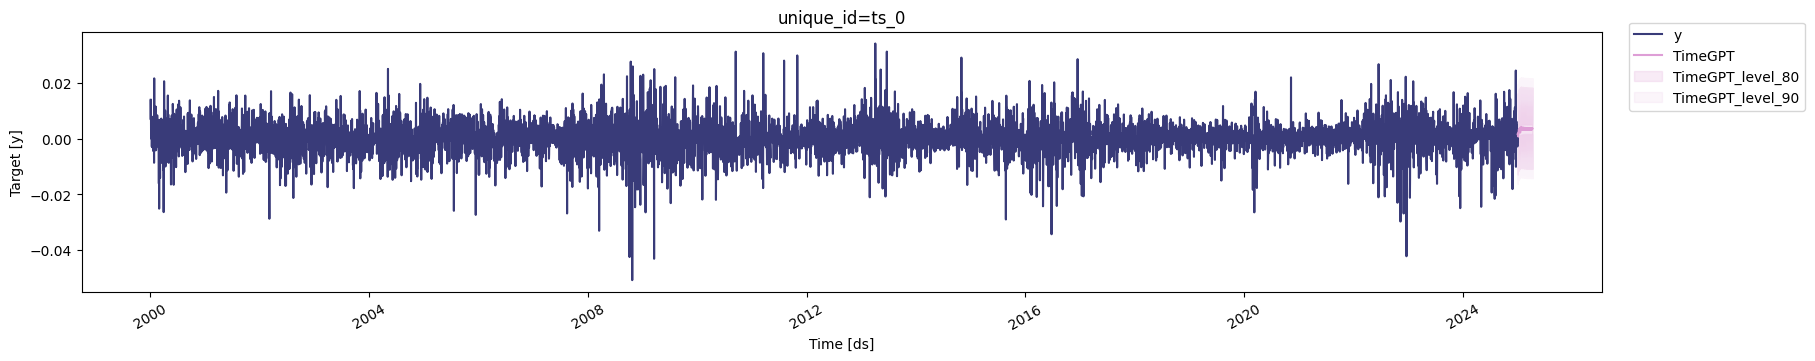

In [4]:
# Get your API Key at dashboard.nixtla.io

# 1. Instantiate the NixtlaClient
nixtla_client = NixtlaClient(api_key = api_key)

# 2. Read historic data
df = pd.read_csv('/Users/alexzheng/Developer/GitHub/Forecasting-Yen-Carry-Trade-Risk-Using-an-LLM/data/returns.csv')

# Reset the index to convert "Date" from the index to a column
df.reset_index(inplace=True)

# Rename columns to match Nixtla's format
df.rename(columns={'Date': 'ds', 'carry_trade_returns': 'y'}, inplace=True)
# Convert the "ds" column to datetime format (just in case)
df['ds'] = pd.to_datetime(df['ds'])


# 3. Forecast the next 100 days
fcst_df = nixtla_client.forecast(df, h=100, level=[80, 90])

# 4. Plot your results (optional)
nixtla_client.plot(df, fcst_df, level=[80, 90])


In [5]:
fcst_df.head(10)

,ds,TimeGPT,TimeGPT-hi-80,TimeGPT-hi-90,TimeGPT-lo-80,TimeGPT-lo-90
0,2025-01-01,0.001647,0.016215,0.019568,-0.012921,-0.016273
1,2025-01-02,0.001614,0.009920,0.010731,-0.006692,-0.007502
2,2025-01-03,0.000817,0.011318,0.015737,-0.009684,-0.014102
3,2025-01-04,0.000760,0.002629,0.002894,-0.001108,-0.001374
4,2025-01-05,0.001494,0.003500,0.003789,-0.000513,-0.000801
5,2025-01-06,0.002286,0.010517,0.012703,-0.005945,-0.008131
6,2025-01-07,0.002341,0.009513,0.010443,-0.004832,-0.005761
7,2025-01-08,0.003061,0.017629,0.020981,-0.011507,-0.014860
8,2025-01-09,0.003385,0.011691,0.012502,-0.004921,-0.005731
9,2025-01-10,0.002415,0.012916,0.017334,-0.008086,-0.012505


### Anomaly detection using TimeGPT in 3 easy steps

In [6]:
# # Get your API Key at dashboard.nixtla.io

# # 1. Instantiate the NixtlaClient
# nixtla_client = NixtlaClient(api_key = api_key)

# # 2. Read Data # Wikipedia visits of NFL Star (
# df = pd.read_csv('https://datasets-nixtla.s3.amazonaws.com/peyton-manning.csv')


# # 3. Detect Anomalies
# anomalies_df = nixtla_client.detect_anomalies(df, time_col='timestamp', target_col='value', freq='D')

# # 4. Plot your results (optional)
# nixtla_client.plot(df, anomalies_df,time_col='timestamp', target_col='value')